# Sesion 2 - Metro Madrid: estacionalidad compleja y prediccion practica

Objetivo de la sesion:
- Modelar una serie real con fuerte estructura de calendario.
- Separar senal determinista (tendencia + estacionalidades) de ruido/incertidumbre.
- Comparar modelos por error puntual y por calidad de intervalos de confianza.

Objetivo pedagogico:
- Mostrar el ciclo real del trabajo de un data scientist: observar, modelar, diagnosticar fallos, refinar y volver a validar.

Conexion con la sesion 1:
- En FX (no estacionaria), el foco principal era rango de riesgo.
- En Metro, ademas de incertidumbre, buscamos capturar explicitamente estacionalidad semanal y anual.




## 1) Librerias

Base metodologica:
- `STL`: descomposicion interpretable de tendencia/estacionalidad/residuo.
- `SARIMAX`: modelo clasico para estructura temporal y estacional.
- `ExponentialSmoothing (ETS)`: baseline robusto para nivel/tendencia/estacionalidad.
- `Prophet`: alternativa muy usada en negocio para tendencia + multiples estacionalidades + changepoints.
- Metricas: `MAE`, `RMSE`, `Cobertura IC95`, `% fuera IC95`.



In [43]:
# Importamos librerias de limpieza, visualizacion, descomposicion y modelos clasicos para comparar enfoques.
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)



## 2) Carga y limpieza minima

Principio practico:
- Sin calidad de dato temporal, no hay modelo fiable.

Que hacemos y por que:
1. Parseo de fechas y orden temporal.
2. Conversion numerica de demanda.
3. Reindexado diario para garantizar regularidad temporal.
4. Imputacion simple de huecos (interpolacion temporal + arrastre) para no romper modelos.
5. Guardado de version limpia (`data/processed`) para trazabilidad.



In [44]:
# Cargamos fichero original.
# Leemos la demanda diaria de Metro Madrid desde el CSV original del repo.
df = pd.read_csv("../data/raw/demanda_diaria_metro_2015_2024.csv")

# Parseamos fecha.
# Parsear la fecha es clave para ordenar, reindexar y resamplear correctamente.
df["Fecha"] = pd.to_datetime(df["Fecha"])

# Renombramos para trabajar con nombres consistentes.
df = df.rename(columns={"Fecha": "date", "Demanda": "y"})

# Convertimos y a numerico y limpiamos nulos.
# Convertimos la demanda a numerico por robustez frente a datos mal tipados.
df["y"] = pd.to_numeric(df["y"], errors="coerce")
df = df.dropna(subset=["y"]).sort_values("date")

# Indice temporal diario.
# El indice temporal diario simplifica toda la logica posterior del notebook.
df = df.set_index("date")

# Reindexamos a diario por robustez y rellenamos posibles huecos.
# Reindexamos a diario para detectar y rellenar huecos del fichero original.
idx = pd.date_range(df.index.min(), df.index.max(), freq="D")
df = df.reindex(idx)
# Interpolamos en el tiempo y cubrimos bordes para dejar la serie completa.
df["y"] = df["y"].interpolate(method="time").ffill().bfill()

print("Filas:", len(df))
print("Inicio:", df.index.min())
print("Fin:", df.index.max())
print("Nulos:", df["y"].isna().sum())



Filas: 3622
Inicio: 2015-01-01 00:00:00
Fin: 2024-11-30 00:00:00
Nulos: 0


In [45]:
# Guardar la serie limpia da trazabilidad entre dato bruto y dato modelado.
# Guardamos limpio para trazabilidad.
df.reset_index().rename(columns={"index": "date"}).to_csv("../data/processed/metro_daily_clean.csv", index=False)



## 3) EDA de dominio

Lectura de negocio antes de modelar:
- Nivel global de demanda y su evolucion.
- Cambios de regimen (COVID).
- Patron semanal (laborables vs fin de semana).
- Patron anual (meses, vacaciones, navidad, etc.).

Esta fase define las hipotesis de modelado (que componente debe capturar el modelo y que parte queda como ruido).



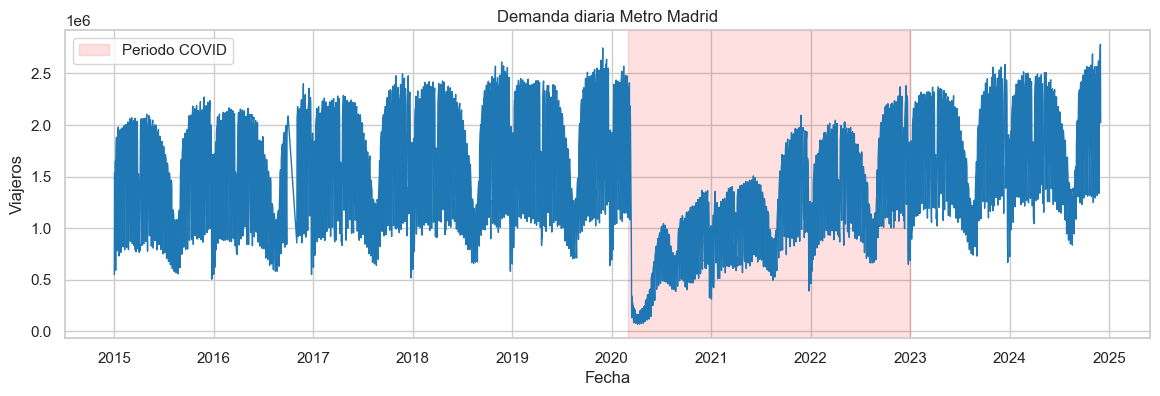

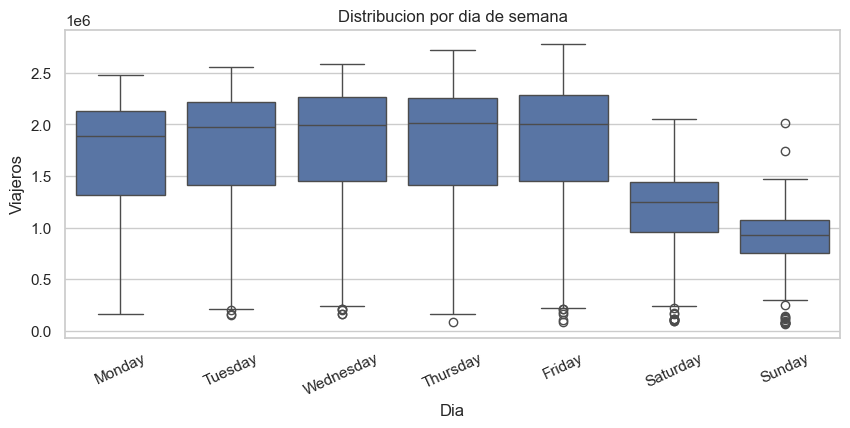

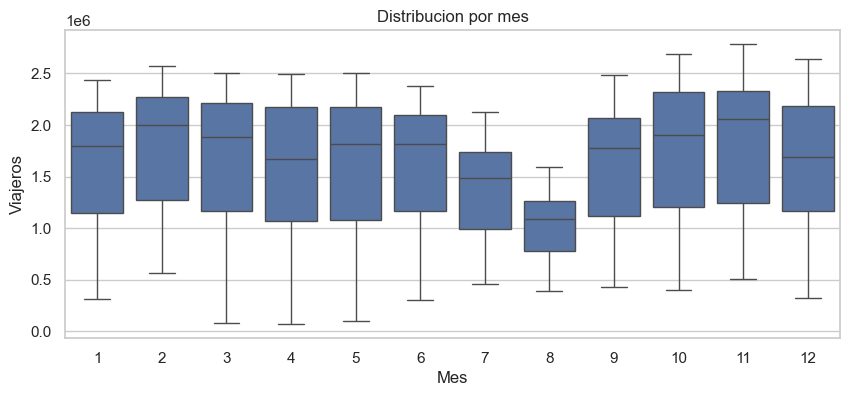

In [46]:
# Marcamos periodo COVID para analisis visual.
# Marcamos explicitamente el tramo COVID para leer la ruptura estructural de movilidad.
covid_start = pd.Timestamp("2020-03-01")
covid_end = pd.Timestamp("2022-12-31")
df["is_covid"] = (df.index >= covid_start) & (df.index <= covid_end)

# Serie completa con banda COVID.
# La primera figura da contexto general antes de bajar a patrones semanales y mensuales.
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["y"], color="tab:blue", linewidth=1)
plt.axvspan(covid_start, covid_end, color="red", alpha=0.12, label="Periodo COVID")
plt.title("Demanda diaria Metro Madrid")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")
plt.legend()
plt.show()

# Variables de calendario para analisis estacional.
# Creamos una copia auxiliar para exploracion sin contaminar la tabla principal.
df_eda = df.copy()
df_eda["dow"] = df_eda.index.day_name()
df_eda["month"] = df_eda.index.month

# Patron semanal.
# Ordenamos manualmente los dias para que el boxplot siga el calendario natural.
order_dow = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_eda, x="dow", y="y", order=order_dow)
plt.title("Distribucion por dia de semana")
plt.xlabel("Dia")
plt.ylabel("Viajeros")
plt.xticks(rotation=25)
plt.show()

# Patron anual por mes.
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_eda, x="month", y="y")
plt.title("Distribucion por mes")
plt.xlabel("Mes")
plt.ylabel("Viajeros")
plt.show()



### 3.1) Zoom de un ano completo (detalle semanal + anual)

Finalidad didactica:
- Ver simultaneamente estructura semanal (ciclos cortos) y anual intra-ano.
- Detectar eventos y atipicos (festivos, verano, puentes).

Que mirar:
- Serie diaria (ruido + senal)
- Media movil 7 dias (estructura semanal)
- Media movil 30 dias (estructura de medio plazo)
- Distribucion de fines de semana frente a laborables



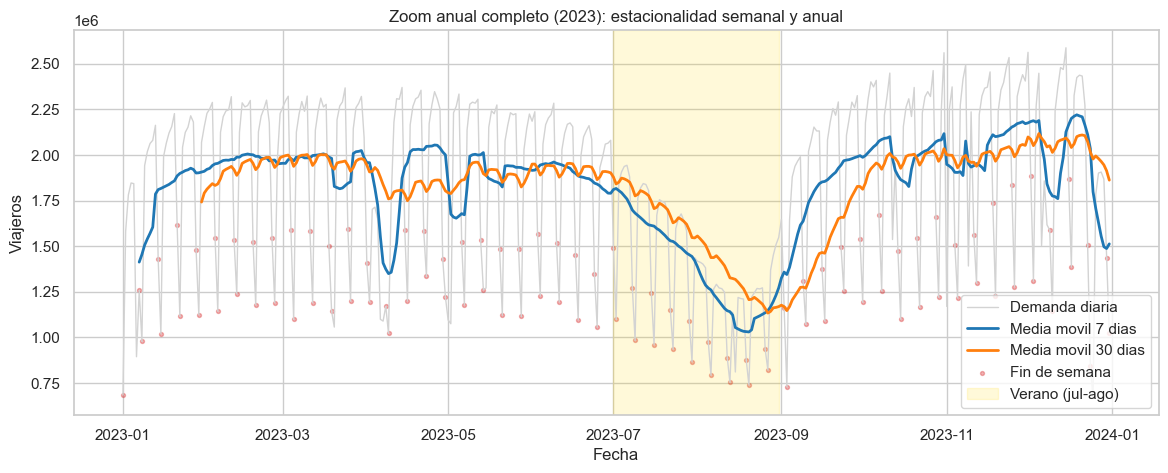

In [47]:
# Elegimos el ultimo ano completo disponible en la serie.
# Buscamos el ultimo anio completo para evitar graficar un tramo recortado.
full_years = []
for y in sorted(df.index.year.unique()):
    i0 = pd.Timestamp(f"{y}-01-01")
    i1 = pd.Timestamp(f"{y}-12-31")
    if i0 in df.index and i1 in df.index:
        full_years.append(y)

if len(full_years) == 0:
    raise ValueError("No hay anos completos en la serie para el zoom anual")

year_zoom = max(full_years)
start_y = pd.Timestamp(f"{year_zoom}-01-01")
end_y = pd.Timestamp(f"{year_zoom}-12-31")

df_year = df.loc[start_y:end_y].copy()

# Suavizados para leer mejor estructura semanal y anual.
# La media movil semanal aclara el patron intrasemanal sobre la serie cruda.
df_year["ma_7"] = df_year["y"].rolling(7).mean()
df_year["ma_30"] = df_year["y"].rolling(30).mean()

# Mascara fin de semana para marcar patron semanal.
# Marcar fines de semana ayuda a conectar visualmente calendario y caidas de demanda.
is_weekend = df_year.index.weekday >= 5

plt.figure(figsize=(14, 5))

# Serie diaria (ruidosa) en gris.
plt.plot(df_year.index, df_year["y"], color="lightgray", linewidth=1, label="Demanda diaria")

# Medias moviles para estructura temporal.
plt.plot(df_year.index, df_year["ma_7"], color="tab:blue", linewidth=2, label="Media movil 7 dias")
plt.plot(df_year.index, df_year["ma_30"], color="tab:orange", linewidth=2, label="Media movil 30 dias")

# Marcamos fines de semana (patron semanal).
plt.scatter(df_year.index[is_weekend], df_year.loc[is_weekend, "y"], s=8, color="tab:red", alpha=0.35, label="Fin de semana")

# Marcamos verano para lectura de estacionalidad anual.
summer_start = pd.Timestamp(f"{year_zoom}-07-01")
summer_end = pd.Timestamp(f"{year_zoom}-08-31")
plt.axvspan(summer_start, summer_end, color="gold", alpha=0.15, label="Verano (jul-ago)")

plt.title(f"Zoom anual completo ({year_zoom}): estacionalidad semanal y anual")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")
plt.legend(loc="best")
plt.show()



## 4) Descomposicion: tendencia + estacionalidad anual + estacionalidad semanal + ruido

Identidad aditiva de trabajo:

`serie_observada = tendencia + estacionalidad_semanal + estacionalidad_anual + ruido`

Interpretacion:
- **Determinista**: tendencia + estacionalidades (parte explicable).
- **Aleatoria**: ruido/residuo (incertidumbre no explicada).

Notas tecnicas:
- `STL(period=7)` nos da una separacion robusta de componente semanal.
- La estacionalidad anual se aproxima con efecto mensual centrado (media cero) para no mezclar nivel con tendencia.
- El residuo es clave para calibrar intervalos de confianza.

Importante:
- Esta descomposicion es una herramienta de entendimiento y diagnostico.
- Por si sola no garantiza el mejor forecast: hay que validar contra modelos predictivos en pseudo-test.




Error medio absoluto de reconstruccion: 0.000000


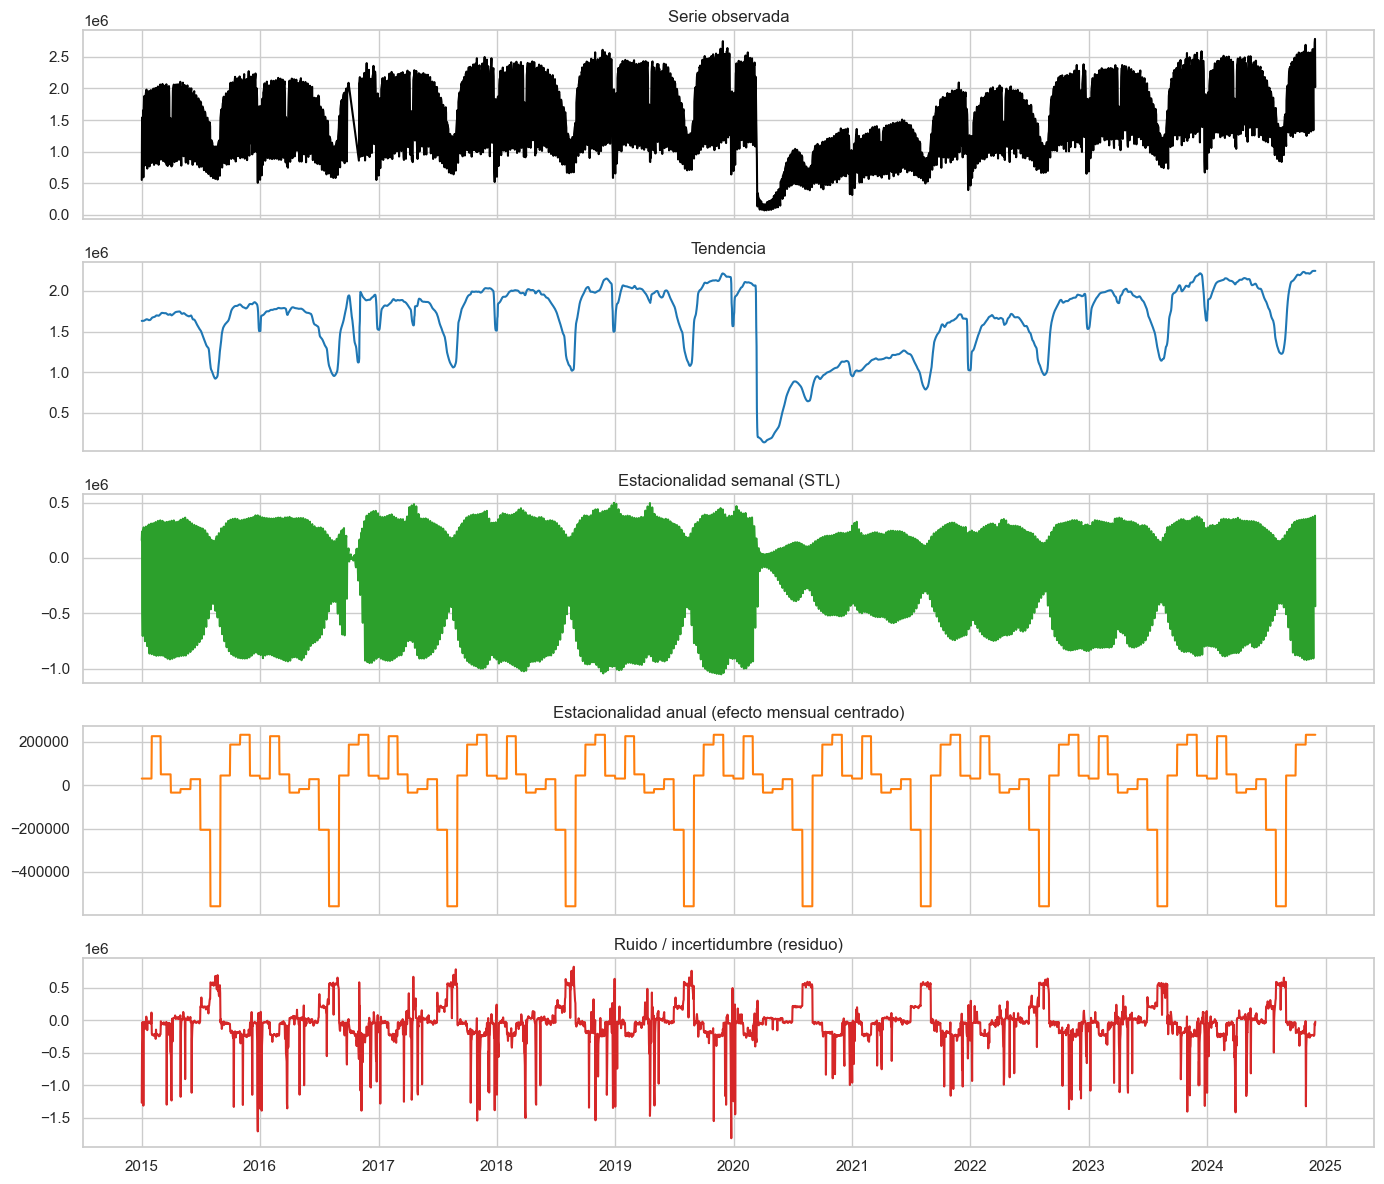

In [48]:
# STL semanal para separar tendencia/estacionalidad/residuo.
# STL con periodo 7 descompone la serie segun el ciclo semanal dominante.
stl = STL(df["y"], period=7, robust=True).fit()

# Componentes STL.
# Guardamos los componentes para inspeccionarlos y reconstruir la parte explicada.
df["trend_stl"] = stl.trend
df["seasonal_weekly_stl"] = stl.seasonal
df["resid_stl"] = stl.resid

# Estacionalidad anual explicita: efecto mensual centrado (media cero).
# 1) media por mes del ano.
month_mean = df.groupby(df.index.month)["y"].mean()
# 2) nivel medio global.
global_mean = df["y"].mean()
# 3) efecto anual centrado.
month_effect_centered = month_mean - global_mean
# 4) asignamos el efecto a cada fila segun su mes.
df["seasonal_annual"] = df.index.month.map(month_effect_centered)

# Identidad aditiva completa.
# Sumamos tendencia y estacionalidades para obtener una primera aproximacion de parte determinista.
df["deterministic_part"] = (
    df["trend_stl"]
    + df["seasonal_weekly_stl"]
    + df["seasonal_annual"]
)

df["noise_part"] = df["y"] - df["deterministic_part"]

# Verificacion numerica de la identidad (error medio absoluto de reconstruccion).
reconstruction_error = (
    df["y"]
    - (df["trend_stl"] + df["seasonal_weekly_stl"] + df["seasonal_annual"] + df["noise_part"])
).abs().mean()
print(f"Error medio absoluto de reconstruccion: {reconstruction_error:.6f}")

# Graficos de componentes.
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df.index, df["y"], color="black")
axes[0].set_title("Serie observada")

axes[1].plot(df.index, df["trend_stl"], color="tab:blue")
axes[1].set_title("Tendencia")

axes[2].plot(df.index, df["seasonal_weekly_stl"], color="tab:green")
axes[2].set_title("Estacionalidad semanal (STL)")

axes[3].plot(df.index, df["seasonal_annual"], color="tab:orange")
axes[3].set_title("Estacionalidad anual (efecto mensual centrado)")

axes[4].plot(df.index, df["noise_part"], color="tab:red")
axes[4].set_title("Ruido / incertidumbre (residuo)")

plt.tight_layout()
plt.show()



In [49]:
# Estas estadisticas del residuo ayudan a interpretar el nivel de incertidumbre que queda sin explicar.
# Estadisticas del ruido para interpretar incertidumbre.
noise_std = df["noise_part"].std()
noise_mean = df["noise_part"].mean()

print(f"Media del ruido: {noise_mean:.2f}")
print(f"Desviacion tipica del ruido: {noise_std:.2f}")
print("Interpretacion: esta dispersion es la base para construir intervalos razonables.")



Media del ruido: -43418.92
Desviacion tipica del ruido: 298992.36
Interpretacion: esta dispersion es la base para construir intervalos razonables.


## 4.1) Refinamiento de descomposicion: diagnostico y mejora

Lectura critica del resultado anterior (razonamiento de data scientist):
- En la tendencia aparecen valles recurrentes en verano y navidad; eso sugiere fuga de estacionalidad anual hacia tendencia.
- En el residuo se observa sesgo por epoca del ano (meses con residuo medio sistematicamente > 0 o < 0), senal de estacionalidad anual incompleta.

Por que pasa con el enfoque base:
- El efecto anual por media mensual centrada es util como aproximacion inicial, pero es demasiado rigido para una serie diaria compleja.
- La estacionalidad real anual no siempre cabe en 12 escalones fijos (verano, navidad, puentes, cambios de habito).

Refinamiento que aplicamos ahora:
1. Pasar a descomposicion multiestacional real con periodos `7` y `365` cuando haya `MSTL`.
2. Si `MSTL` no esta disponible, usar un fallback secuencial robusto:
   - STL semanal para separar patron de 7 dias.
   - STL anual sobre serie sin efecto semanal para capturar ciclo anual diario.
3. Mantener esquema aditivo e inspeccionar si el residuo mensual queda mas centrado en cero.

Checklist de validacion tras refinar:
- la tendencia pierde oscilaciones claramente anuales
- el residuo reduce sesgo por mes
- la reconstruccion mantiene error numerico cercano a cero

Objetivo didactico:
- Mostrar que un modelo no se da por cerrado al primer intento: se diagnostica, se corrige y se vuelve a evaluar visualmente.




Metodo de refinamiento usado: MSTL(periods=[7,365], robust=True)
Error medio absoluto de reconstruccion (refinado): 0.000000

Sesgo medio del residuo por mes (base vs refinado):


,residuo_base,residuo_refinado
mes,,
1,-102112.77,-20818.55
2,-231666.61,374.71
3,-123036.75,-134825.18
4,-22538.74,-208336.48
5,-63072.95,-125763.37
6,-28320.33,-76403.91
7,207447.12,-18641.69
8,537114.20,11416.92
9,-51307.78,-27376.23


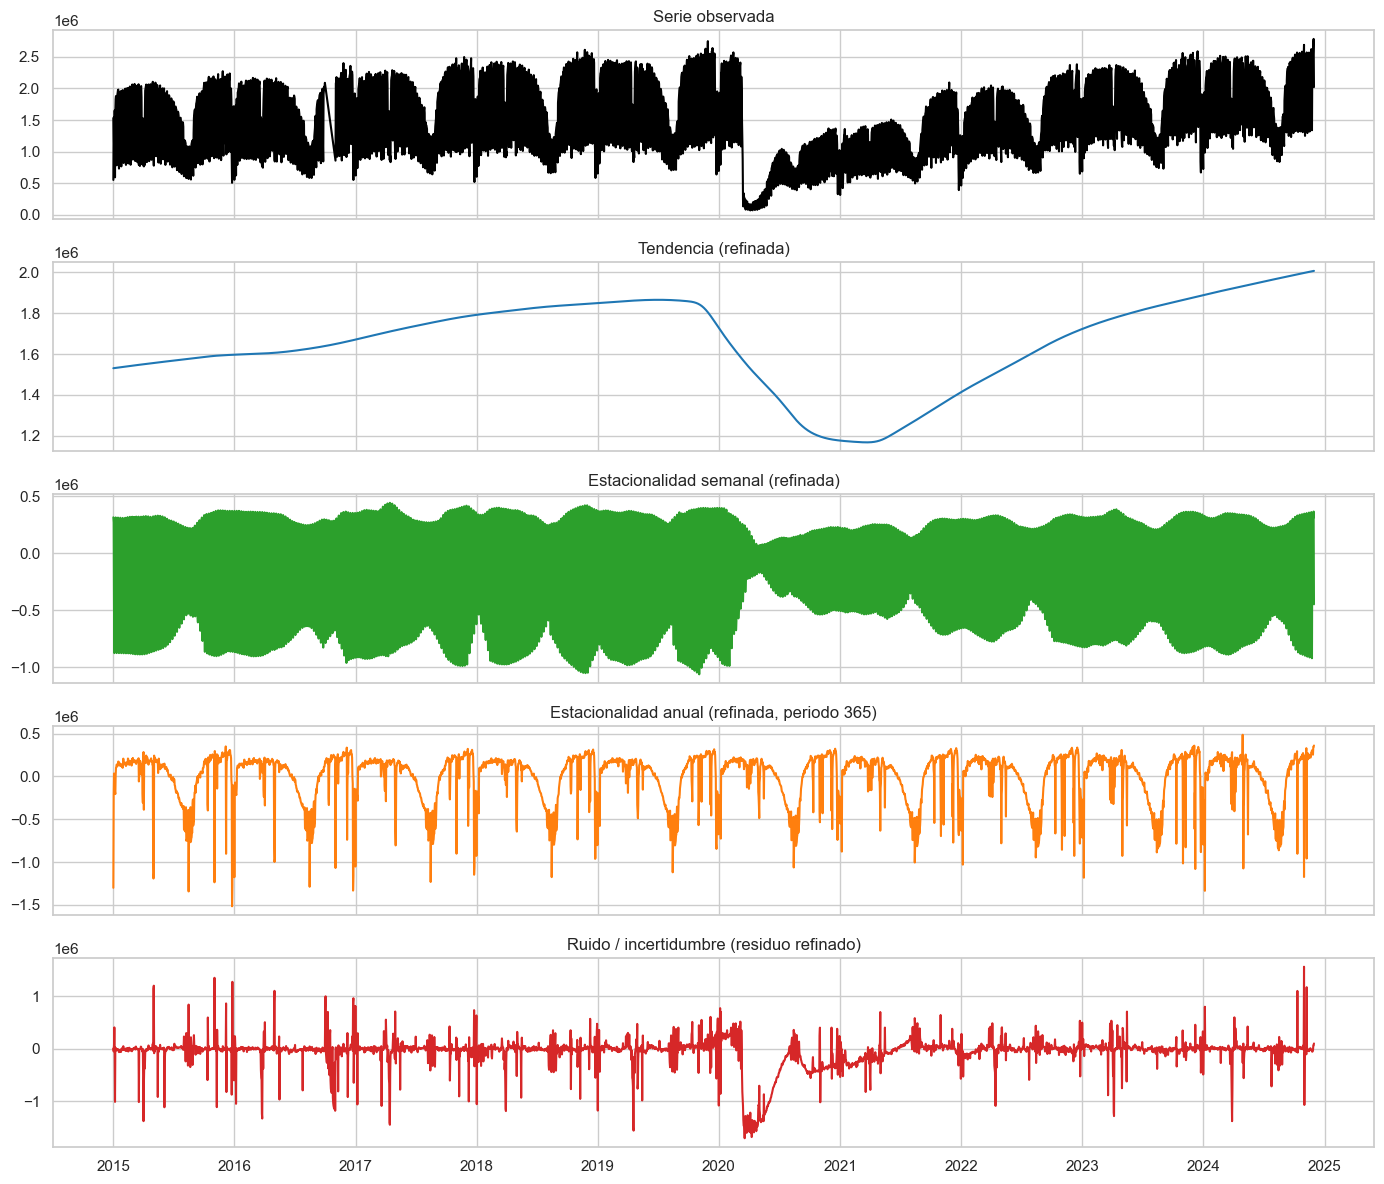

In [50]:
# Refinamiento multiestacional: semanal (7) + anual diario (365).
# Primero intentamos MSTL; si no esta disponible, usamos STL secuencial como fallback.

method_refined = None
# Intentamos una descomposicion multiestacional mas rica: semanal y anual a la vez.
try:
    from statsmodels.tsa.seasonal import MSTL

    # MSTL estima simultaneamente varias estacionalidades y suele ser la opcion mas limpia si esta disponible.
    mstl_fit = MSTL(df["y"], periods=[7, 365], stl_kwargs={"robust": True}).fit()
    seas = mstl_fit.seasonal

    # Detectamos columnas de estacionalidad por nombre para robustez entre versiones.
    cols = list(seas.columns)
    col_week = [c for c in cols if "7" in str(c)][0]
    col_year = [c for c in cols if "365" in str(c)][0]

    df["seasonal_weekly_refined"] = seas[col_week]
    df["seasonal_annual_refined"] = seas[col_year]
    df["trend_refined"] = mstl_fit.trend
    method_refined = "MSTL(periods=[7,365], robust=True)"

# Si MSTL no esta disponible, hacemos un fallback secuencial para mantener la idea metodologica.
except Exception as e:
    # Fallback: descomposicion secuencial robusta.
    stl_week = STL(df["y"], period=7, robust=True).fit()
    y_without_weekly = df["y"] - stl_week.seasonal

    stl_year = STL(y_without_weekly, period=365, robust=True).fit()

    df["seasonal_weekly_refined"] = stl_week.seasonal
    df["seasonal_annual_refined"] = stl_year.seasonal
    df["trend_refined"] = stl_year.trend
    method_refined = "STL secuencial (7 -> 365), robust=True"
    print("MSTL no disponible; usando fallback secuencial:", e)

# Reconstruccion y residuo refinado.
df["deterministic_part_refined"] = (
    df["trend_refined"]
    + df["seasonal_weekly_refined"]
    + df["seasonal_annual_refined"]
)
df["noise_part_refined"] = df["y"] - df["deterministic_part_refined"]

# Verificacion de identidad aditiva.
reconstruction_error_refined = (
    df["y"]
    - (df["trend_refined"] + df["seasonal_weekly_refined"] + df["seasonal_annual_refined"] + df["noise_part_refined"])
).abs().mean()

print(f"Metodo de refinamiento usado: {method_refined}")
print(f"Error medio absoluto de reconstruccion (refinado): {reconstruction_error_refined:.6f}")

# Diagnostico rapido del sesgo mensual del residuo (antes vs despues).
if "noise_part" in df.columns:
    old_bias = df.groupby(df.index.month)["noise_part"].mean()
    new_bias = df.groupby(df.index.month)["noise_part_refined"].mean()
    bias_cmp = pd.DataFrame({"residuo_base": old_bias, "residuo_refinado": new_bias})
    bias_cmp.index.name = "mes"
    print("\nSesgo medio del residuo por mes (base vs refinado):")
    display(bias_cmp.round(2))

# Grafica de componentes refinados (misma logica visual que la celda anterior).
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df.index, df["y"], color="black")
axes[0].set_title("Serie observada")

axes[1].plot(df.index, df["trend_refined"], color="tab:blue")
axes[1].set_title("Tendencia (refinada)")

axes[2].plot(df.index, df["seasonal_weekly_refined"], color="tab:green")
axes[2].set_title("Estacionalidad semanal (refinada)")

axes[3].plot(df.index, df["seasonal_annual_refined"], color="tab:orange")
axes[3].set_title("Estacionalidad anual (refinada, periodo 365)")

axes[4].plot(df.index, df["noise_part_refined"], color="tab:red")
axes[4].set_title("Ruido / incertidumbre (residuo refinado)")

plt.tight_layout()
plt.show()


## 5) Forecast medio plazo: viajeros medios de los proximos 12 meses

Escenario practico:
- Planificacion de capacidad, presupuesto y operacion mensual.

Fundamento de modelos:
- **SARIMA mensual**: modela dependencia temporal + estacionalidad anual (periodo 12).
  - Lectura funcional: SARIMA extiende ARIMA para series con ciclos repetitivos.
  - Estructura general: `SARIMA(p,d,q)(P,D,Q,s)`, donde `s` es el periodo estacional (`s=12` en mensual con ciclo anual).
  - `p,d,q` describen dinamica no estacional (corto plazo).
  - `P,D,Q` describen dinamica estacional (patrones que se repiten cada `s` periodos).
  - Se usa cuando hay memoria temporal + patron estacional claro y se requiere interpretabilidad.

  Ejemplo de este notebook: `order=(1,1,1)` y `seasonal_order=(1,1,1,12)`
  - `d=1`: elimina tendencia no estacional de la serie mensual.
  - `p=1`: usa el ultimo rezago no estacional.
  - `q=1`: corrige con el ultimo error no estacional.
  - `D=1`: diferencia estacional anual (comparacion con el mismo mes del ano previo).
  - `P=1`: incorpora memoria estacional de 12 meses.
  - `Q=1`: corrige con error estacional reciente.

  Casos tipicos de uso de SARIMA:
  - Demanda mensual con patron anual (transporte, energia, retail).
  - Series donde la estacionalidad es estable y no depende de muchas variables externas.
  - Como baseline interpretable antes de modelos mas flexibles.
- **ETS mensual**: modela nivel/tendencia/estacionalidad de forma suavizada.
- **Prophet mensual**: modela tendencia con changepoints + estacionalidades de calendario + intervalo de incertidumbre.

Estrategia:
1. Agregar a serie mensual media.
2. Reservar ultimos 12 meses como pseudo-test.
3. Comparar modelos con:
   - Error puntual: MAE, RMSE
   - Incertidumbre: Cobertura IC95 y % fuera de intervalo
4. Incorporar modelo decomposition-based para comparar enfoque explicativo vs modelos estandar.
5. Reentrenar con todo el historico y proyectar proximos 12 meses.

Criterio de seleccion recomendado:
- priorizar MAE/RMSE si el caso exige precision puntual
- priorizar calibracion de IC si el caso exige gestion de riesgo operativo
- en caso de empate, preferir el modelo mas interpretable y estable en el tiempo




In [51]:
# Serie mensual (promedio de viajeros diarios por mes).
# Pasar a mensual reduce ruido diario y facilita una comparativa docente entre modelos.
monthly = df["y"].resample("MS").mean()

# Pseudo-test: ultimos 12 meses.
# Reservamos el ultimo anio como pseudo-test mensual para comparar fuera de muestra.
train_m = monthly.iloc[:-12]
test_m = monthly.iloc[-12:]

# Modelo 1: SARIMA mensual con estacionalidad anual (12).
# SARIMA combina dinamica temporal y estacionalidad anual de 12 meses.
sarima_m = SARIMAX(train_m, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_m_fit = sarima_m.fit(disp=False)
fc_m = sarima_m_fit.get_forecast(steps=12)
sarima_m_pred = fc_m.predicted_mean
sarima_m_ci = fc_m.conf_int(alpha=0.05)
sarima_m_lo = sarima_m_ci.iloc[:, 0]
sarima_m_hi = sarima_m_ci.iloc[:, 1]

# Modelo 2: Holt-Winters (ETS aditivo).
# ETS sirve como alternativa clasica de suavizado exponencial con tendencia y estacionalidad aditiva.
ets_m = ExponentialSmoothing(train_m, trend="add", seasonal="add", seasonal_periods=12).fit()
ets_m_pred = ets_m.forecast(12)
ets_sigma = pd.Series(ets_m.resid).std()
ets_m_lo = ets_m_pred - 1.96 * ets_sigma
ets_m_hi = ets_m_pred + 1.96 * ets_sigma

# Modelo 3: Prophet mensual (integrado, no bloque aparte).
prophet_monthly_available = False
try:
    from prophet import Prophet

    train_p_m = train_m.reset_index()
    train_p_m.columns = ["ds", "y"]

    model_p_m = Prophet(
        interval_width=0.95,
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
    )
    model_p_m.fit(train_p_m)

    future_p_m = model_p_m.make_future_dataframe(periods=12, freq="MS")
    fc_p_m = model_p_m.predict(future_p_m)

    fc_p_m_test = fc_p_m.set_index("ds").loc[test_m.index]
    prophet_m_pred = fc_p_m_test["yhat"]
    prophet_m_lo = fc_p_m_test["yhat_lower"]
    prophet_m_hi = fc_p_m_test["yhat_upper"]

    prophet_monthly_available = True
except Exception as e:
    print("Prophet mensual no disponible en esta ejecucion:", e)

# Metricas y cobertura.
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rows_m = [
    {
        "Modelo": "SARIMA mensual",
        "MAE": mean_absolute_error(test_m, sarima_m_pred),
        "RMSE": rmse(test_m, sarima_m_pred),
        "Cobertura_IC95": ((test_m >= sarima_m_lo) & (test_m <= sarima_m_hi)).mean(),
    },
    {
        "Modelo": "ETS mensual",
        "MAE": mean_absolute_error(test_m, ets_m_pred),
        "RMSE": rmse(test_m, ets_m_pred),
        "Cobertura_IC95": ((test_m >= ets_m_lo) & (test_m <= ets_m_hi)).mean(),
    },
]

if prophet_monthly_available:
    rows_m.append(
        {
            "Modelo": "Prophet mensual",
            "MAE": mean_absolute_error(test_m, prophet_m_pred),
            "RMSE": rmse(test_m, prophet_m_pred),
            "Cobertura_IC95": ((test_m >= prophet_m_lo) & (test_m <= prophet_m_hi)).mean(),
        }
    )

summary_m = pd.DataFrame(rows_m)
summary_m["%Fuera_IC95"] = 1 - summary_m["Cobertura_IC95"]
summary_m = summary_m[["Modelo", "MAE", "RMSE", "Cobertura_IC95", "%Fuera_IC95"]]
summary_m = summary_m.sort_values("Modelo").reset_index(drop=True)
summary_m = summary_m.round({"MAE": 6, "RMSE": 6, "Cobertura_IC95": 6, "%Fuera_IC95": 6})
summary_m




10:02:59 - cmdstanpy - INFO - Chain [1] start processing
10:02:59 - cmdstanpy - INFO - Chain [1] done processing


,Modelo,MAE,RMSE,Cobertura_IC95,%Fuera_IC95
0,ETS mensual,80510.822645,113209.809794,1.000000,0.000000
1,Prophet mensual,443027.832098,456919.122101,0.916667,0.083333
2,SARIMA mensual,74429.019222,103068.323501,1.000000,0.000000


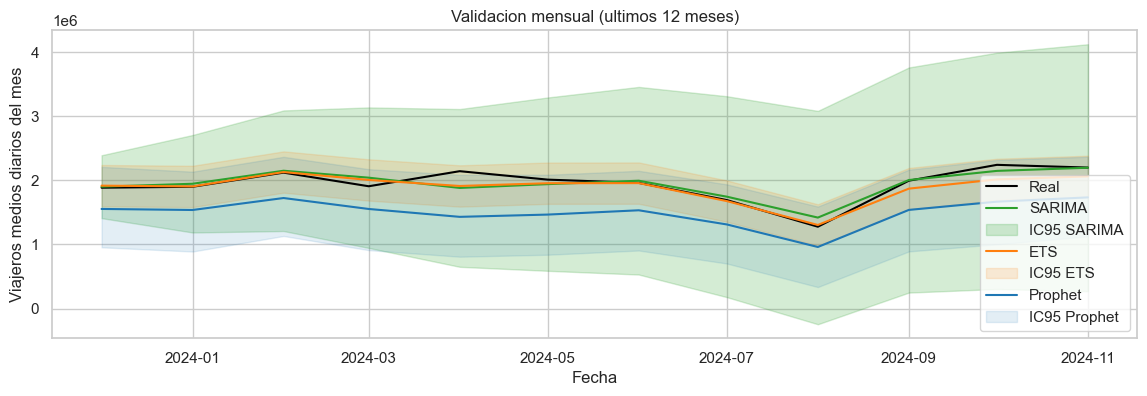

In [52]:
# Reunimos en una sola figura el pseudo-test mensual para comparar forma e intervalos.
# Visual comparativa en pseudo-test mensual (una sola grafica).
plt.figure(figsize=(14, 4))
plt.plot(test_m.index, test_m.values, label="Real", color="black")

plt.plot(test_m.index, sarima_m_pred.values, label="SARIMA", color="tab:green")
plt.fill_between(test_m.index, sarima_m_lo.values, sarima_m_hi.values, color="tab:green", alpha=0.2, label="IC95 SARIMA")

plt.plot(test_m.index, ets_m_pred.values, label="ETS", color="tab:orange")
plt.fill_between(test_m.index, ets_m_lo.values, ets_m_hi.values, color="tab:orange", alpha=0.15, label="IC95 ETS")

if 'prophet_monthly_available' in globals() and prophet_monthly_available:
    plt.plot(test_m.index, prophet_m_pred.values, label="Prophet", color="tab:blue")
    plt.fill_between(test_m.index, prophet_m_lo.values, prophet_m_hi.values, color="tab:blue", alpha=0.12, label="IC95 Prophet")

plt.title("Validacion mensual (ultimos 12 meses)")
plt.xlabel("Fecha")
plt.ylabel("Viajeros medios diarios del mes")
plt.legend(loc="best")
plt.show()



In [53]:
# Estas tablas complementan MAE/RMSE con propiedades descriptivas de las predicciones.
# Estadisticos de prediccion mensual (ademas de MAE/RMSE).
rows_stats_m = [
    {
        "Modelo": "SARIMA mensual",
        "Media_pred": sarima_m_pred.mean(),
        "Std_pred": sarima_m_pred.std(),
        "Media_intervalo_95": (sarima_m_hi - sarima_m_lo).mean(),
        "Min_pred": sarima_m_pred.min(),
        "Max_pred": sarima_m_pred.max(),
    },
    {
        "Modelo": "ETS mensual",
        "Media_pred": ets_m_pred.mean(),
        "Std_pred": ets_m_pred.std(),
        "Media_intervalo_95": (ets_m_hi - ets_m_lo).mean(),
        "Min_pred": ets_m_pred.min(),
        "Max_pred": ets_m_pred.max(),
    },
]

if 'prophet_monthly_available' in globals() and prophet_monthly_available:
    rows_stats_m.append(
        {
            "Modelo": "Prophet mensual",
            "Media_pred": prophet_m_pred.mean(),
            "Std_pred": prophet_m_pred.std(),
            "Media_intervalo_95": (prophet_m_hi - prophet_m_lo).mean(),
            "Min_pred": prophet_m_pred.min(),
            "Max_pred": prophet_m_pred.max(),
        }
    )

monthly_pred_stats = pd.DataFrame(rows_stats_m)
monthly_pred_stats



,Modelo,Media_pred,Std_pred,Media_intervalo_95,Min_pred,Max_pred
0,SARIMA mensual,1.946880e+06,209611.972317,2.679223e+06,1.419103e+06,2.196029e+06
1,ETS mensual,1.891964e+06,216267.502264,6.439337e+05,1.304128e+06,2.128764e+06
2,Prophet mensual,1.500762e+06,207701.081551,1.256292e+06,9.606954e+05,1.733914e+06


### 5.1) Modelo adicional: decomposition-based forecast (a partir de componentes refinadas)

Idea:
- En vez de tratar la serie mensual como un bloque unico, predecimos componentes y luego reconstruimos `y`.
- Formula: `y_hat = trend_hat + seasonal_weekly_hat + seasonal_annual_hat + resid_hat`.
- En este enfoque, `resid_hat` se toma con media 0 y su dispersion se usa para intervalos.
- La descomposicion usada aqui es exactamente la refinada en el bloque 4.1 (misma base metodologica).

Ventajas e inconvenientes en esta serie (vs modelos estandar):
- **SARIMA mensual**
  - Ventaja: interpretable y competitivo cuando la estacionalidad anual es estable.
  - Inconveniente: una sola estacionalidad explicita por modelo; menor flexibilidad ante cambios de patron.
- **ETS mensual**
  - Ventaja: muy robusto para nivel/tendencia/estacionalidad suave con poco tuning.
  - Inconveniente: menos explicito para choques de calendario y cambios estructurales.
- **Prophet mensual**
  - Ventaja: incorpora changepoints y estacionalidades de calendario con facilidad.
  - Inconveniente: puede sobreamortiguar o desalinear amplitudes si la estructura real no coincide con sus supuestos.
- **Decomposition-based (nuevo)**
  - Ventaja: maximo control e interpretabilidad por componente; muy didactico para diagnostico.
  - Inconveniente: mas decisiones manuales (cada componente puede introducir error propio).




In [54]:
# Modelo adicional: forecast por componentes refinadas + reconstruccion.
# Requiere haber ejecutado el bloque 4.1 de refinamiento.

# Antes de reconstruir el forecast, comprobamos que las componentes refinadas existen.
required_cols = [
    "trend_refined",
    "seasonal_weekly_refined",
    "seasonal_annual_refined",
    "noise_part_refined",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Faltan columnas refinadas: {missing}. Ejecuta antes la seccion 4.1")

# Pasamos componentes refinadas a frecuencia mensual (promedio mensual).
# Resampleamos cada componente a frecuencia mensual para pronosticarlas y recomponer la serie.
comp_m = pd.DataFrame({
    "trend_m": df["trend_refined"].resample("MS").mean(),
    "weekly_m": df["seasonal_weekly_refined"].resample("MS").mean(),
    "annual_m": df["seasonal_annual_refined"].resample("MS").mean(),
    "noise_m": df["noise_part_refined"].resample("MS").mean(),
}).dropna()

# Mismo split mensual para comparacion justa con SARIMA/ETS/Prophet.
train_comp = comp_m.loc[train_m.index]
test_comp = comp_m.loc[test_m.index]

# 1) Trend: ETS con tendencia aditiva sobre la componente de tendencia.
trend_comp_fit = ExponentialSmoothing(train_comp["trend_m"], trend="add", seasonal=None).fit()
trend_comp_pred = trend_comp_fit.forecast(len(test_comp))

# 2) Estacionalidad anual y 3) estacionalidad semanal agregada mensual:
#    estimacion por perfil medio mensual (month-of-year) en train.
annual_profile = train_comp.groupby(train_comp.index.month)["annual_m"].mean()
weekly_profile = train_comp.groupby(train_comp.index.month)["weekly_m"].mean()

annual_comp_pred = pd.Series([annual_profile[m] for m in test_comp.index.month], index=test_comp.index)
weekly_comp_pred = pd.Series([weekly_profile[m] for m in test_comp.index.month], index=test_comp.index)

# 4) Residuo: media esperada 0; incertidumbre desde desviacion historica del residuo mensual.
decomp_m_pred = trend_comp_pred + annual_comp_pred + weekly_comp_pred
sigma_decomp = train_comp["noise_m"].std()
decomp_m_lo = decomp_m_pred - 1.96 * sigma_decomp
decomp_m_hi = decomp_m_pred + 1.96 * sigma_decomp

# Metricas en pseudo-test mensual.
row_decomp = {
    "Modelo": "Decomp refinado mensual",
    "MAE": mean_absolute_error(test_m, decomp_m_pred),
    "RMSE": rmse(test_m, decomp_m_pred),
    "Cobertura_IC95": ((test_m >= decomp_m_lo) & (test_m <= decomp_m_hi)).mean(),
}

summary_m_plus = pd.concat([summary_m, pd.DataFrame([row_decomp])], ignore_index=True)
summary_m_plus["%Fuera_IC95"] = 1 - summary_m_plus["Cobertura_IC95"]
summary_m_plus = summary_m_plus[["Modelo", "MAE", "RMSE", "Cobertura_IC95", "%Fuera_IC95"]]
summary_m_plus = summary_m_plus.sort_values("MAE").reset_index(drop=True)
summary_m_plus = summary_m_plus.round({"MAE": 6, "RMSE": 6, "Cobertura_IC95": 6, "%Fuera_IC95": 6})

print("Comparativa mensual extendida (incluye decomposition-based):")
summary_m_plus


Comparativa mensual extendida (incluye decomposition-based):


,Modelo,MAE,RMSE,Cobertura_IC95,%Fuera_IC95
0,Decomp refinado mensual,44412.967176,62381.468445,1.000000,0.000000
1,SARIMA mensual,74429.019222,103068.323501,1.000000,0.000000
2,ETS mensual,80510.822645,113209.809794,1.000000,0.000000
3,Prophet mensual,443027.832098,456919.122101,0.916667,0.083333


#### Visualizacion del decomposition-based en pseudo-test

Comparamos la serie real mensual frente al forecast por componentes refinadas y su intervalo de confianza al 95%.



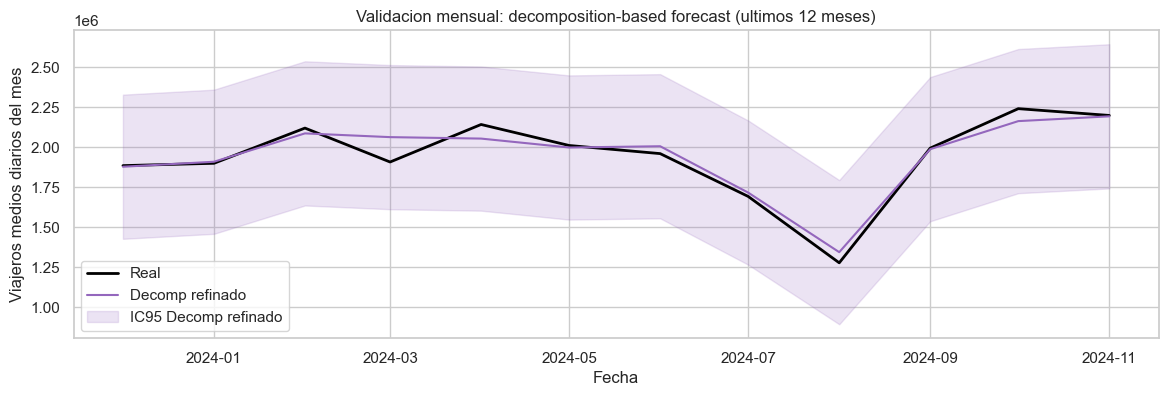

In [55]:
# Visualizamos el forecast por descomposicion refinada para juzgar si la reconstruccion es coherente.
# Visual del modelo decomposition-based en pseudo-test mensual.
plt.figure(figsize=(14, 4))
plt.plot(test_m.index, test_m.values, label="Real", color="black", linewidth=2)
plt.plot(decomp_m_pred.index, decomp_m_pred.values, label="Decomp refinado", color="tab:purple")
plt.fill_between(
    decomp_m_pred.index,
    decomp_m_lo.values,
    decomp_m_hi.values,
    color="tab:purple",
    alpha=0.18,
    label="IC95 Decomp refinado",
)
plt.title("Validacion mensual: decomposition-based forecast (ultimos 12 meses)")
plt.xlabel("Fecha")
plt.ylabel("Viajeros medios diarios del mes")
plt.legend(loc="best")
plt.show()


#### Comparativa conjunta: 4 modelos con intervalos

Figura unica para comparar en la misma ventana temporal los 4 modelos del bloque mensual (SARIMA, ETS, Prophet y Decomp refinado), junto con sus IC95.

Como leer esta grafica:
- cercania de cada curva a la serie real (precision)
- anchura del intervalo (incertidumbre)
- porcentaje de puntos reales dentro/fuera del intervalo (calibracion)



Prophet mensual no disponible en esta ejecucion; la comparativa se muestra con 3 modelos + decomp.


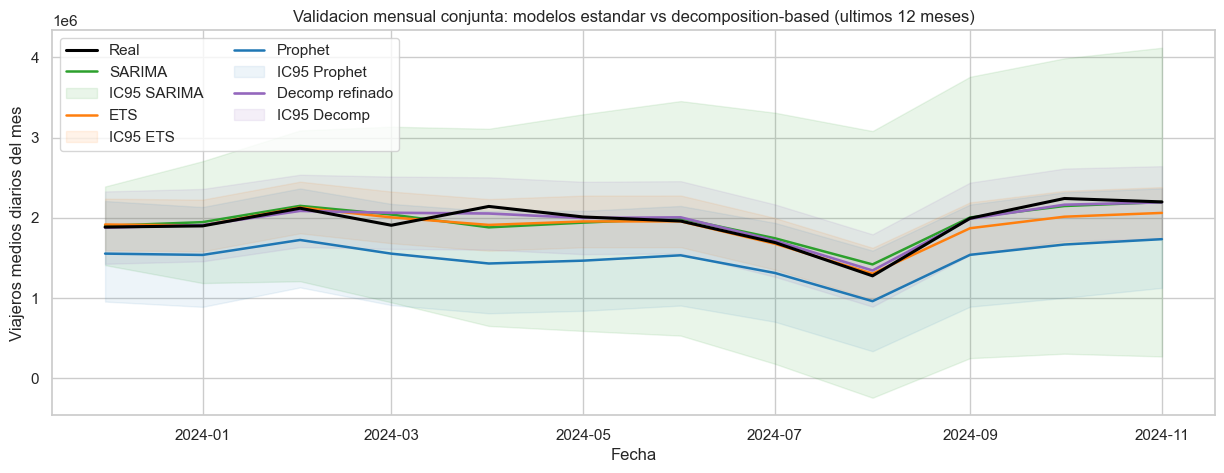

In [56]:
# Visual comparativa conjunta: 4 modelos mensuales + intervalos de confianza.
# Esta figura pone todos los modelos mensuales en el mismo eje temporal para comparacion directa.
plt.figure(figsize=(15, 5))

# Serie real
plt.plot(test_m.index, test_m.values, label="Real", color="black", linewidth=2.2, zorder=5)

# SARIMA
plt.plot(test_m.index, sarima_m_pred.values, label="SARIMA", color="tab:green", linewidth=1.8)
plt.fill_between(test_m.index, sarima_m_lo.values, sarima_m_hi.values, color="tab:green", alpha=0.10, label="IC95 SARIMA")

# ETS
plt.plot(test_m.index, ets_m_pred.values, label="ETS", color="tab:orange", linewidth=1.8)
plt.fill_between(test_m.index, ets_m_lo.values, ets_m_hi.values, color="tab:orange", alpha=0.09, label="IC95 ETS")

# Prophet
if "prophet_monthly_available" in globals() and prophet_monthly_available:
    plt.plot(test_m.index, prophet_m_pred.values, label="Prophet", color="tab:blue", linewidth=1.8)
    plt.fill_between(test_m.index, prophet_m_lo.values, prophet_m_hi.values, color="tab:blue", alpha=0.08, label="IC95 Prophet")
#else:
    print("Prophet mensual no disponible en esta ejecucion; la comparativa se muestra con 3 modelos + decomp.")

# Decomposition-based
plt.plot(decomp_m_pred.index, decomp_m_pred.values, label="Decomp refinado", color="tab:purple", linewidth=1.9)
plt.fill_between(decomp_m_pred.index, decomp_m_lo.values, decomp_m_hi.values, color="tab:purple", alpha=0.10, label="IC95 Decomp")

plt.title("Validacion mensual conjunta: modelos estandar vs decomposition-based (ultimos 12 meses)")
plt.xlabel("Fecha")
plt.ylabel("Viajeros medios diarios del mes")
plt.legend(loc="best", ncol=2)
plt.show()


In [57]:
# Forecast real: proximos 12 meses usando el mejor modelo en pseudo-test (MAE).

# Elegimos el modelo mensual ganador por MAE y lo reentrenamos con todo el historico.
summary_selector = summary_m_plus if "summary_m_plus" in globals() else summary_m
best_monthly_model = summary_selector.sort_values("MAE").iloc[0]["Modelo"]
print(f"Modelo mensual seleccionado por MAE: {best_monthly_model}")

monthly_full = monthly.copy()

if best_monthly_model == "SARIMA mensual":
    m_full = SARIMAX(monthly_full, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
    fc = m_full.get_forecast(steps=12)
    future_pred = fc.predicted_mean
    future_ci = fc.conf_int(alpha=0.05)
    lower = future_ci.iloc[:, 0]
    upper = future_ci.iloc[:, 1]

elif best_monthly_model == "ETS mensual":
    m_full = ExponentialSmoothing(monthly_full, trend="add", seasonal="add", seasonal_periods=12).fit()
    future_pred = m_full.forecast(12)
    sigma = pd.Series(m_full.resid).std()
    lower = future_pred - 1.96 * sigma
    upper = future_pred + 1.96 * sigma

elif best_monthly_model == "Prophet mensual":
    from prophet import Prophet
    train_p = monthly_full.reset_index()
    train_p.columns = ["ds", "y"]

    m_full = Prophet(
        interval_width=0.95,
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
    )
    m_full.fit(train_p)

    future_df = m_full.make_future_dataframe(periods=12, freq="MS")
    fc = m_full.predict(future_df)
    fc_last = fc.set_index("ds").iloc[-12:]

    future_pred = fc_last["yhat"]
    lower = fc_last["yhat_lower"]
    upper = fc_last["yhat_upper"]

elif best_monthly_model == "Decomp refinado mensual":
    if not all(col in df.columns for col in ["trend_refined", "seasonal_weekly_refined", "seasonal_annual_refined", "noise_part_refined"]):
        raise ValueError("Faltan componentes refinadas para forecast decomposition-based. Ejecuta antes la seccion 4.1")

    comp_m_full = pd.DataFrame({
        "trend_m": df["trend_refined"].resample("MS").mean(),
        "weekly_m": df["seasonal_weekly_refined"].resample("MS").mean(),
        "annual_m": df["seasonal_annual_refined"].resample("MS").mean(),
        "noise_m": df["noise_part_refined"].resample("MS").mean(),
    }).dropna()

    trend_full_fit = ExponentialSmoothing(comp_m_full["trend_m"], trend="add", seasonal=None).fit()
    trend_future = trend_full_fit.forecast(12)

    annual_profile_full = comp_m_full.groupby(comp_m_full.index.month)["annual_m"].mean()
    weekly_profile_full = comp_m_full.groupby(comp_m_full.index.month)["weekly_m"].mean()

    future_index = pd.date_range(monthly_full.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq="MS")
    annual_future = pd.Series([annual_profile_full[m] for m in future_index.month], index=future_index)
    weekly_future = pd.Series([weekly_profile_full[m] for m in future_index.month], index=future_index)

    future_pred = trend_future.values + annual_future.values + weekly_future.values
    future_pred = pd.Series(future_pred, index=future_index)

    sigma = comp_m_full["noise_m"].std()
    lower = future_pred - 1.96 * sigma
    upper = future_pred + 1.96 * sigma

else:
    raise ValueError(f"Modelo mensual no reconocido: {best_monthly_model}")

future_m_table = pd.DataFrame(
    {
        "y_pred": future_pred.values,
        "y_lower_95": lower.values,
        "y_upper_95": upper.values,
    },
    index=future_pred.index,
)
future_m_table



Modelo mensual seleccionado por MAE: Decomp refinado mensual


,y_pred,y_lower_95,y_upper_95
2024-12-01,2.007172e+06,1.577121e+06,2.437222e+06
2025-01-01,2.035382e+06,1.605332e+06,2.465432e+06
2025-02-01,2.217779e+06,1.787729e+06,2.647830e+06
2025-03-01,2.186212e+06,1.756162e+06,2.616263e+06
2025-04-01,2.183079e+06,1.753029e+06,2.613129e+06
2025-05-01,2.122691e+06,1.692641e+06,2.552741e+06
2025-06-01,2.123773e+06,1.693723e+06,2.553824e+06
2025-07-01,1.837762e+06,1.407712e+06,2.267812e+06
2025-08-01,1.460405e+06,1.030355e+06,1.890455e+06
2025-09-01,2.107437e+06,1.677386e+06,2.537487e+06


## 6) Forecast corto plazo: viajeros diarios del proximo mes

Escenario practico:
- Programacion operativa diaria (frecuencias, personal, incidencias).

Fundamento de modelos:
- **SARIMAX diario**: captura autocorrelacion y estacionalidad semanal explicita (periodo 7).
- **NHITS diario**: modelo deep learning especializado para patrones temporales no lineales.
- **Prophet diario**: alternativa de negocio con tendencia + estacionalidad semanal/anual + incertidumbre.

Estrategia:
1. Pseudo-test de ultimos 30 dias.
2. Comparar modelos con MAE, RMSE, cobertura IC95 y % fuera IC95.
3. Proyectar proximos 30 dias con intervalo de confianza.

Decision operativa esperada:
- dimensionar recursos diarios con el punto medio de forecast
- usar IC95 para definir escenarios de demanda alta/baja y planes de contingencia




In [58]:
# Pseudo-test diario: ultimos 30 dias.
# En diario dejamos los ultimos 30 dias como pseudo-test de corto plazo.
train_d = df["y"].iloc[:-30]
test_d = df["y"].iloc[-30:]

# Modelo base: naive estacional semanal (lag 7).
# El naive semanal copia el mismo dia de la semana anterior, un baseline fuerte en esta serie.
naive_d_pred = pd.concat([train_d, test_d]).shift(7).loc[test_d.index]
naive_sigma = (train_d - train_d.shift(7)).dropna().std()
naive_d_lo = naive_d_pred - 1.96 * naive_sigma
naive_d_hi = naive_d_pred + 1.96 * naive_sigma

# Modelo SARIMAX diario con estacionalidad semanal.
# SARIMAX diario introduce explicitamente el ciclo semanal de 7 dias.
sarimax_d = SARIMAX(train_d, order=(1, 0, 1), seasonal_order=(1, 0, 1, 7), enforce_stationarity=False, enforce_invertibility=False)
sarimax_d_fit = sarimax_d.fit(disp=False)
fc_d = sarimax_d_fit.get_forecast(steps=30)
sarimax_d_pred = fc_d.predicted_mean
sarimax_d_ci = fc_d.conf_int(alpha=0.05)
sarimax_d_lo = sarimax_d_ci.iloc[:, 0]
sarimax_d_hi = sarimax_d_ci.iloc[:, 1]

# Prophet diario integrado.
prophet_daily_available = False
try:
    from prophet import Prophet

    train_p_d = train_d.reset_index()
    train_p_d.columns = ["ds", "y"]

    model_p_d = Prophet(
        interval_width=0.95,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
    )
    model_p_d.fit(train_p_d)

    future_p_d = model_p_d.make_future_dataframe(periods=30, freq="D")
    fc_p_d = model_p_d.predict(future_p_d)

    fc_p_d_test = fc_p_d.set_index("ds").loc[test_d.index]
    prophet_d_pred = fc_p_d_test["yhat"]
    prophet_d_lo = fc_p_d_test["yhat_lower"]
    prophet_d_hi = fc_p_d_test["yhat_upper"]

    prophet_daily_available = True
except Exception as e:
    print("Prophet diario no disponible en esta ejecucion:", e)



10:03:01 - cmdstanpy - INFO - Chain [1] start processing
10:03:02 - cmdstanpy - INFO - Chain [1] done processing


### 6.1) Bonus sofisticado: NHITS (deep learning especializado)

Por que incluirlo:
- Es un modelo moderno para series temporales, util como contraste frente a modelos clasicos.

Criterio pedagogico:
- No asumir que "mas complejo" implica mejor.
- Validar igual que los modelos clasicos: MAE, RMSE y calidad de intervalos.



In [59]:
# BONUS: NHITS en diario (mismo pseudo-test de 30 dias).
# El bonus diario con NHITS muestra como adaptar la misma serie a un modelo deep learning.
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
from neuralforecast.losses.pytorch import MQLoss

# NeuralForecast requiere columnas ds, y y unique_id.
train_nf = train_d.to_frame("y").reset_index().rename(columns={"index": "ds"})
train_nf["unique_id"] = "METRO"
train_nf = train_nf[["unique_id", "ds", "y"]]

nhits_d = NHITS(
    h=30,
    input_size=min(180, len(train_nf) - 1),
    max_steps=250,
    loss=MQLoss(level=[95]),
    random_seed=7,
)

nf_d = NeuralForecast(models=[nhits_d], freq="D")
nf_d.fit(df=train_nf)
fc_nh = nf_d.predict().reset_index().sort_values("ds")

# Nombres directos de salida NHITS.
nhits_d_pred = fc_nh["NHITS-median"].values
nhits_d_lo = fc_nh["NHITS-lo-95"].values
nhits_d_hi = fc_nh["NHITS-hi-95"].values

# Tabla comparativa diaria con todos los modelos disponibles.
rows_d = [
    {
        "Modelo": "Naive semanal",
        "MAE": mean_absolute_error(test_d, naive_d_pred),
        "RMSE": rmse(test_d, naive_d_pred),
        "Cobertura_IC95": ((test_d >= naive_d_lo) & (test_d <= naive_d_hi)).mean(),
    },
    {
        "Modelo": "SARIMAX diario",
        "MAE": mean_absolute_error(test_d, sarimax_d_pred),
        "RMSE": rmse(test_d, sarimax_d_pred),
        "Cobertura_IC95": ((test_d >= sarimax_d_lo) & (test_d <= sarimax_d_hi)).mean(),
    },
    {
        "Modelo": "NHITS diario",
        "MAE": mean_absolute_error(test_d.values, nhits_d_pred),
        "RMSE": rmse(test_d.values, nhits_d_pred),
        "Cobertura_IC95": ((test_d.values >= nhits_d_lo) & (test_d.values <= nhits_d_hi)).mean(),
    },
]

if 'prophet_daily_available' in globals() and prophet_daily_available:
    rows_d.append(
        {
            "Modelo": "Prophet diario",
            "MAE": mean_absolute_error(test_d, prophet_d_pred),
            "RMSE": rmse(test_d, prophet_d_pred),
            "Cobertura_IC95": ((test_d >= prophet_d_lo) & (test_d <= prophet_d_hi)).mean(),
        }
    )

summary_d = pd.DataFrame(rows_d)
summary_d["%Fuera_IC95"] = 1 - summary_d["Cobertura_IC95"]
summary_d = summary_d[["Modelo", "MAE", "RMSE", "Cobertura_IC95", "%Fuera_IC95"]]
summary_d = summary_d.sort_values("Modelo").reset_index(drop=True)
summary_d = summary_d.round({"MAE": 6, "RMSE": 6, "Cobertura_IC95": 6, "%Fuera_IC95": 6})
summary_d




Seed set to 7
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MQLoss        | 3      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 2.9 M  | train | 0    
---------------------------------------------------------------
2.9 M     Trainable params
3         Non-trainable params
2.9 M     Total params
11.627    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=250` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting: |          | 0/? [00:00<?, ?it/s]

,Modelo,MAE,RMSE,Cobertura_IC95,%Fuera_IC95
0,NHITS diario,190860.695833,283530.789426,0.966667,0.033333
1,Naive semanal,134998.666667,298920.125241,0.933333,0.066667
2,Prophet diario,124221.588384,210351.562070,0.966667,0.033333
3,SARIMAX diario,146910.256961,252509.608750,0.966667,0.033333


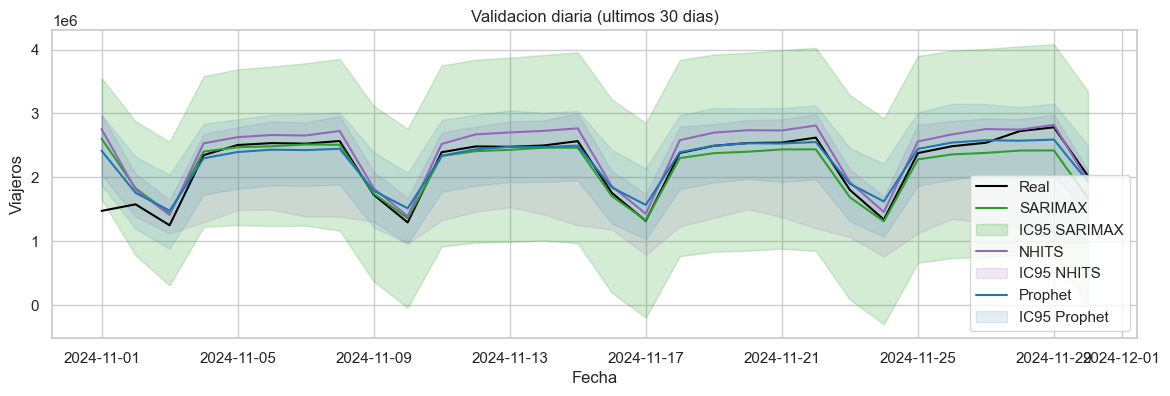

In [60]:
# Esta grafica resume el pseudo-test diario y permite comparar trayectorias e intervalos.
# Visual comparativa diaria en pseudo-test (30 dias) en una sola grafica.
plt.figure(figsize=(14, 4))
plt.plot(test_d.index, test_d.values, label="Real", color="black")

plt.plot(test_d.index, sarimax_d_pred.values, label="SARIMAX", color="tab:green")
plt.fill_between(test_d.index, sarimax_d_lo.values, sarimax_d_hi.values, color="tab:green", alpha=0.2, label="IC95 SARIMAX")

plt.plot(test_d.index, nhits_d_pred, label="NHITS", color="tab:purple")
plt.fill_between(test_d.index, nhits_d_lo, nhits_d_hi, color="tab:purple", alpha=0.15, label="IC95 NHITS")

if 'prophet_daily_available' in globals() and prophet_daily_available:
    plt.plot(test_d.index, prophet_d_pred.values, label="Prophet", color="tab:blue")
    plt.fill_between(test_d.index, prophet_d_lo.values, prophet_d_hi.values, color="tab:blue", alpha=0.12, label="IC95 Prophet")

plt.title("Validacion diaria (ultimos 30 dias)")
plt.xlabel("Fecha")
plt.ylabel("Viajeros")
plt.legend(loc="best")
plt.show()



In [61]:
# Igual que en mensual, resumimos dispersion y anchura media de intervalos en el bloque diario.
# Estadisticos de prediccion diaria.
rows_stats_d = [
    {
        "Modelo": "Naive semanal",
        "Media_pred": np.mean(naive_d_pred),
        "Std_pred": np.std(naive_d_pred),
        "Media_intervalo_95": np.mean(naive_d_hi - naive_d_lo),
        "Min_pred": np.min(naive_d_pred),
        "Max_pred": np.max(naive_d_pred),
    },
    {
        "Modelo": "SARIMAX diario",
        "Media_pred": np.mean(sarimax_d_pred),
        "Std_pred": np.std(sarimax_d_pred),
        "Media_intervalo_95": np.mean(sarimax_d_hi - sarimax_d_lo),
        "Min_pred": np.min(sarimax_d_pred),
        "Max_pred": np.max(sarimax_d_pred),
    },
    {
        "Modelo": "NHITS diario",
        "Media_pred": np.mean(nhits_d_pred),
        "Std_pred": np.std(nhits_d_pred),
        "Media_intervalo_95": np.mean(nhits_d_hi - nhits_d_lo),
        "Min_pred": np.min(nhits_d_pred),
        "Max_pred": np.max(nhits_d_pred),
    },
]

if 'prophet_daily_available' in globals() and prophet_daily_available:
    rows_stats_d.append(
        {
            "Modelo": "Prophet diario",
            "Media_pred": np.mean(prophet_d_pred),
            "Std_pred": np.std(prophet_d_pred),
            "Media_intervalo_95": np.mean(prophet_d_hi - prophet_d_lo),
            "Min_pred": np.min(prophet_d_pred),
            "Max_pred": np.max(prophet_d_pred),
        }
    )

daily_pred_stats = pd.DataFrame(rows_stats_d)
daily_pred_stats



,Modelo,Media_pred,Std_pred,Media_intervalo_95,Min_pred,Max_pred
0,Naive semanal,2.185746e+06,483127.566150,1.243151e+06,1.248664e+06,2.689458e+06
1,SARIMAX diario,2.166041e+06,412765.459772,2.885248e+06,1.310286e+06,2.606148e+06
2,NHITS diario,2.384337e+06,487499.468750,1.308024e+06,1.389629e+06,2.821380e+06
3,Prophet diario,2.242589e+06,364614.056318,1.127697e+06,1.477495e+06,2.591350e+06


In [62]:
# Forecast real: proximos 30 dias con SARIMAX (practico operativo diario).
# Cerramos el notebook con un forecast operativo reentrenando SARIMAX sobre toda la serie.
sarimax_full = SARIMAX(df["y"], order=(1, 0, 1), seasonal_order=(1, 0, 1, 7), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fc_next_30 = sarimax_full.get_forecast(steps=30)
next_30 = fc_next_30.predicted_mean
next_30_ci = fc_next_30.conf_int(alpha=0.05)

next_30_table = pd.DataFrame(
    {
        "y_pred": next_30.values,
        "y_lower_95": next_30_ci.iloc[:, 0].values,
        "y_upper_95": next_30_ci.iloc[:, 1].values,
    },
    index=next_30.index,
)
next_30_table.head(10)



,y_pred,y_lower_95,y_upper_95
2024-12-01,1.543836e+06,5.962496e+05,2.491422e+06
2024-12-02,2.541770e+06,1.490500e+06,3.593039e+06
2024-12-03,2.616497e+06,1.491649e+06,3.741345e+06
2024-12-04,2.624782e+06,1.446229e+06,3.803335e+06
2024-12-05,2.663593e+06,1.445169e+06,3.882017e+06
2024-12-06,2.599708e+06,1.351351e+06,3.848065e+06
2024-12-07,1.877173e+06,6.061732e+05,3.148172e+06
2024-12-08,1.441543e+06,9.773160e+04,2.785354e+06
2024-12-09,2.446545e+06,1.071099e+06,3.821990e+06
2024-12-10,2.531083e+06,1.131687e+06,3.930479e+06


## 7) Cierre conceptual

Mensajes clave:
1. La descomposicion ordena el problema: que parte es senal y que parte es incertidumbre.
2. La comparacion de modelos debe incluir siempre:
   - precision puntual (MAE/RMSE)
   - calibracion de incertidumbre (cobertura IC95).
3. En practica profesional, un modelo util no es solo el que acierta el punto, sino el que entrega rangos fiables para decidir.
4. Refinar el modelo tras diagnosticar errores sistematicos es parte central del trabajo analitico.
5. No existe un modelo universalmente mejor: la eleccion depende de horizonte, coste de error, interpretabilidad y mantenimiento.

Limitaciones de esta demo (importante para uso responsable):
- una sola serie y un numero limitado de configuraciones
- validacion tipo pseudo-test, no backtesting exhaustivo multi-ventana
- sin variables exogenas explicitas (festivos detallados, huelgas, meteorologia, eventos)

Guia reusable para alumnos:
1. Definir pregunta de negocio y horizonte de decision.
2. Auditar calidad temporal del dato.
3. Explorar patrones y posibles rupturas de regimen.
4. Construir baseline interpretable.
5. Medir, diagnosticar y refinar.
6. Reportar supuestos, limites y riesgo de uso.



## 8) Guia de uso rapido en clase

Orden de ejecucion recomendado:
1. Ejecutar todo en secuencia una primera vez.
2. Revisar graficas de diagnostico (EDA + descomposicion + comparativas).
3. Debatir seleccion de modelo segun objetivo (precision vs riesgo).
4. Repetir modificando una sola decision cada vez (horizonte, modelo, estacionalidad) y comparar.

Resultado esperado para alumnos:
- salir con una plantilla completa y reutilizable para analisis de series temporales reales,
- con foco en criterio metodologico, no solo en ejecucion de codigo.

